In [ ]:
# Built-in
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, TimeDistributed, GlobalAveragePooling2D, LSTM, Dense, Dropout
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Scikit-learn
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)


In [ ]:
# Define the path to the dataset
base_path = 'D:\MobileLSTM-HMM-KAN\dataset\\celeb'
categories = ['fake', 'real']

# Initialize a list to hold data
data = []

# Process each category
for category in categories:
    category_path = os.path.join(base_path, category)
    for filename in os.listdir(category_path):
        if filename.endswith('.jpg'):
            try:
                id_part, frame_part = filename.split('_frame_')
                id_ = id_part.split('_')[0]
                frame = frame_part.split('.')[0]
                data.append({
                    'filename': filename,
                    'path': os.path.join(category_path, filename),
                    'id': int(id_),
                    'frame': int(frame),
                    'label': category
                })
            except ValueError:
                continue

# Convert the data to a DataFrame
df = pd.DataFrame(data)
df['label_id'] = df['label'].map({'fake': 0, 'real': 1})

In [ ]:
df['video_key'] = df['id'].astype(str) + "_" + df['label']

from collections import defaultdict

video_dict = defaultdict(list)
labels = {}

for _, row in df.iterrows():
    key = row['video_key']
    video_dict[key].append(row['path'])
    labels[key] = row['label_id']


In [ ]:
# Chuẩn bị dữ liệu
video_keys = list(video_dict.keys())
video_labels = [labels[k] for k in video_keys]

# Cấu hình
img_size = (224, 224)
batch_size = 16
epochs = 50
n_splits = 5
sequence_len = 10
results = []
all_histories = []

# Custom data generator để nạp chuỗi ảnh từ video_dict
class VideoSequence(tf.keras.utils.Sequence):
    def __init__(self, video_keys, video_dict, labels, batch_size, img_size, sequence_len=10, augment=False):
        self.video_keys = video_keys
        self.video_dict = video_dict
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.sequence_len = sequence_len
        self.augment = augment
        self.datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=15 if augment else 0,
            zoom_range=0.1 if augment else 0,
            horizontal_flip=augment
        )

    def __len__(self):
        return int(np.ceil(len(self.video_keys) / self.batch_size))

    def __getitem__(self, idx):
        batch_keys = self.video_keys[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_X, batch_y = [], []

        for key in batch_keys:
            frames = video_dict[key][:self.sequence_len]
            imgs = []
            for path in frames:
                img = cv2.imread(path)
                img = cv2.resize(img, self.img_size)
                img = self.datagen.random_transform(img) if self.augment else img
                img = img.astype('float32') / 255.0
                imgs.append(img)
            while len(imgs) < self.sequence_len:
                imgs.append(np.zeros((*self.img_size, 3), dtype='float32'))  # padding
            batch_X.append(imgs)
            batch_y.append(self.labels[key])

        return np.array(batch_X), np.array(batch_y)

# Hàm xây dựng mô hình
def build_model(sequence_len, img_size):
    base_model = MobileNetV2(input_shape=(*img_size, 3), include_top=False, weights='imagenet')

    # Freeze toàn bộ backbone để giảm overfit
    base_model.trainable = False

    # CNN feature extractor
    model_out = GlobalAveragePooling2D()(base_model.output)
    model = Model(inputs=base_model.input, outputs=model_out)

    # Sequence input
    input_seq = Input(shape=(sequence_len, *img_size, 3))
    x = TimeDistributed(model)(input_seq)

    x = LSTM(64, return_sequences=False)(x)
    x = Dropout(0.5)(x)

    # Không dùng nhiều Dense, chỉ một đầu ra
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=input_seq, outputs=output)
    return model

# K-Fold huấn luyện
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (trainval_idx, test_idx) in enumerate(skf.split(video_keys, video_labels), 1):
    print(f"\n===== Fold {fold} =====")

    trainval_keys = [video_keys[i] for i in trainval_idx]
    test_keys = [video_keys[i] for i in test_idx]

    y_trainval = [labels[k] for k in trainval_keys]
    train_keys, val_keys = train_test_split(trainval_keys, test_size=0.1, stratify=y_trainval, random_state=fold)

    train_gen = VideoSequence(train_keys, video_dict, labels, batch_size, img_size, sequence_len, augment=True)
    val_gen   = VideoSequence(val_keys, video_dict, labels, batch_size, img_size, sequence_len, augment=False)
    test_gen  = VideoSequence(test_keys, video_dict, labels, batch_size, img_size, sequence_len, augment=False)

    model = build_model(sequence_len, img_size)
    model.compile(optimizer=Adamax(learning_rate=1e-4, weight_decay=1e-5), loss='binary_crossentropy', metrics=['accuracy'])

    model_path = f"best_model_fold{fold}.h5"
    checkpoint = ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
    earlystop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

    history = model.fit(train_gen, validation_data=val_gen,
                        epochs=epochs, callbacks=[checkpoint, earlystop, reduce_lr], verbose=1)

    all_histories.append(history.history)

    model.load_weights(model_path)

    y_true = [labels[k] for k in test_keys]
    y_pred_prob = model.predict(test_gen).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

    results.append({
        'fold': fold,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, y_pred_prob)
    })

# Tổng kết kết quả
print("\n📊 Tổng kết kết quả các fold:")
for r in results:
    print(f"Fold {r['fold']}: Accuracy={r['accuracy']:.4f}, F1={r['f1']:.4f}, AUC={r['auc']:.4f}")



===== Fold 1 =====


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5204 - loss: 0.7133
Epoch 1: val_accuracy improved from -inf to 0.43678, saving model to best_model_fold1.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 328s 6s/step - accuracy: 0.5199 - loss: 0.7135 - val_accuracy: 0.4368 - val_loss: 0.7141 - learning_rate: 1.0000e-04
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5101 - loss: 0.7038
Epoch 2: val_accuracy did not improve from 0.43678
49/49 ━━━━━━━━━━━━━━━━━━━━ 226s 5s/step - accuracy: 0.5102 - loss: 0.7037 - val_accuracy: 0.4138 - val_loss: 0.7028 - learning_rate: 1.0000e-04
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5167 - loss: 0.7052
Epoch 3: val_accuracy improved from 0.43678 to 0.52874, saving model to best_model_fold1.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 227s 5s/step - accuracy: 0.5172 - loss: 0.7050 - val_accuracy: 0.5287 - val_loss: 0.6968 - learning_rate: 1.0000e-04
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5719 - loss: 0.6823
Epoch 4: val_accuracy did not improve from 0.52874
49/49 ━━━━━━━━━━━━━━━━━━━━ 231s 5s/step - accuracy: 0.5718 - loss: 0.6823 - val_accuracy: 0.5287 - val_loss: 0.6891 - learning_rate: 1.0000e-04
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5600 - loss: 0.6726
Epoch 5: val_accuracy improved from 0.52874 to 0.55172, saving model to best_model_fold1.h5


...

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4795 - loss: 0.7275
Epoch 1: val_accuracy improved from -inf to 0.58621, saving model to best_model_fold5.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 273s 5s/step - accuracy: 0.4800 - loss: 0.7271 - val_accuracy: 0.5862 - val_loss: 0.6699 - learning_rate: 1.0000e-04
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5543 - loss: 0.7003
Epoch 2: val_accuracy did not improve from 0.58621
49/49 ━━━━━━━━━━━━━━━━━━━━ 217s 4s/step - accuracy: 0.5548 - loss: 0.7000 - val_accuracy: 0.5862 - val_loss: 0.6598 - learning_rate: 1.0000e-04
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6226 - loss: 0.6632
Epoch 3: val_accuracy improved from 0.58621 to 0.62069, saving model to best_model_fold5.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 220s 4s/step - accuracy: 0.6220 - loss: 0.6633 - val_accuracy: 0.6207 - val_loss: 0.6504 - learning_rate: 1.0000e-04
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5893 - loss: 0.6536
Epoch 4: val_accuracy improved from 0.62069 to 0.65517, saving model to best_model_fold5.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 219s 4s/step - accuracy: 0.5894 - loss: 0.6537 - val_accuracy: 0.6552 - val_loss: 0.6385 - learning_rate: 1.0000e-04
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5988 - loss: 0.6647
Epoch 5: val_accuracy did not improve from 0.65517
49/49 ━━━━━━━━━━━━━━━━━━━━ 218s 4s/step - accuracy: 0.5995 - loss: 0.6644 - val_accuracy: 0.6207 - val_loss: 0.6376 - learning_rate: 1.0000e-04
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6592 - loss: 0.6271
Epoch 6: val_accuracy did not improve from 0.65517
49/49 ━━━━━━━━━━━━━━━━━━━━ 261s 4s/step - accuracy: 0.6591 - loss: 0.6272 - val_accuracy: 0.6322 - val_loss: 0.6250 - learning_rate: 1.0000e-04
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6275 - loss: 0.6351
Epoch 7: val_accuracy improved from 0.65517 to 0.68966, saving model to best_model_fold5.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 217s 4s/step - accuracy: 0.6277 - loss: 0.6351 - val_accuracy: 0.6897 - val_loss: 0.6136 - learning_rate: 1.0000e-04
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6656 - loss: 0.6175
Epoch 8: val_accuracy did not improve from 0.68966
49/49 ━━━━━━━━━━━━━━━━━━━━ 217s 4s/step - accuracy: 0.6655 - loss: 0.6176 - val_accuracy: 0.6552 - val_loss: 0.6095 - learning_rate: 1.0000e-04
Epoch 9/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6748 - loss: 0.5997
Epoch 9: val_accuracy did not improve from 0.68966
49/49 ━━━━━━━━━━━━━━━━━━━━ 222s 5s/step - accuracy: 0.6743 - loss: 0.6001 - val_accuracy: 0.6667 - val_loss: 0.6056 - learning_rate: 1.0000e-04
Epoch 10/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6866 - loss: 0.6109
Epoch 10: val_accuracy did not improve from 0.68966
49/49 ━━━━━━━━━━━━━━━━━━━━ 215s 4s/step - accuracy: 0.6866 - loss: 0.6107 - val_accuracy: 0.6782 - val_loss: 0.5986 - learning_rate: 1.0000e-04
Epoch 11/50
49/49 ━━

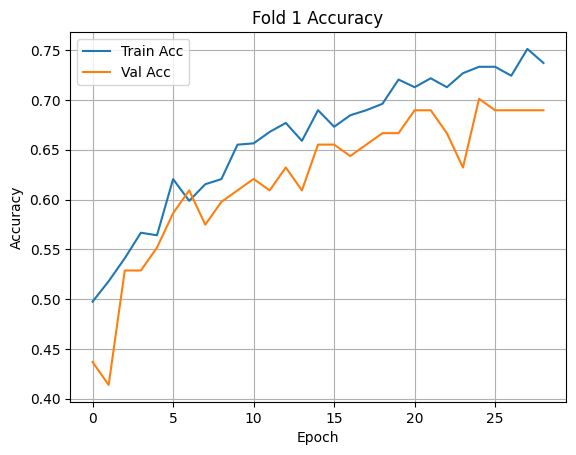

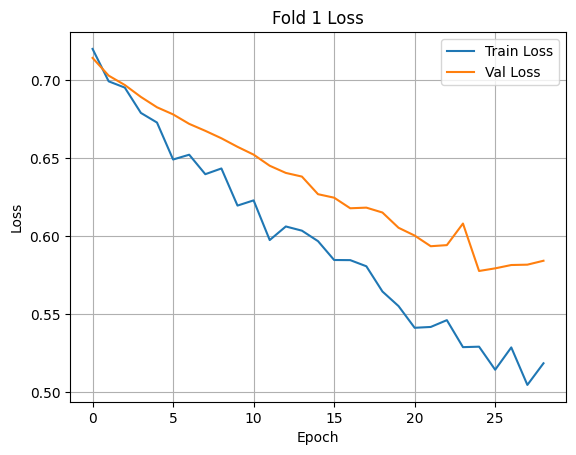

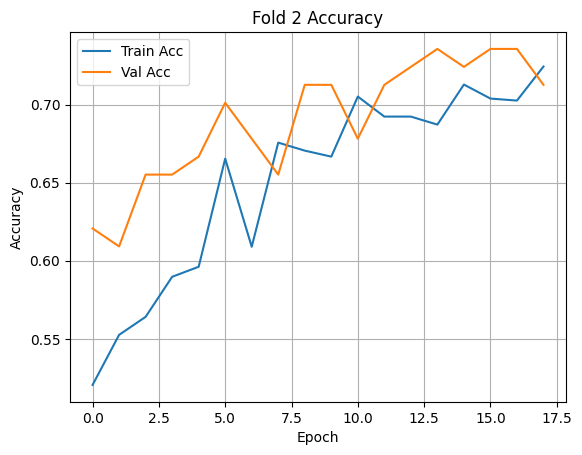

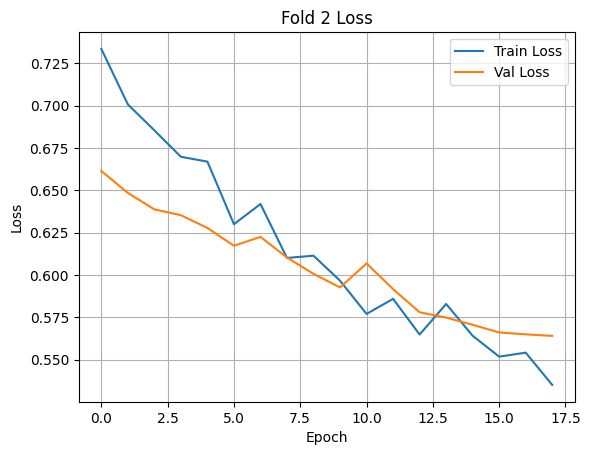

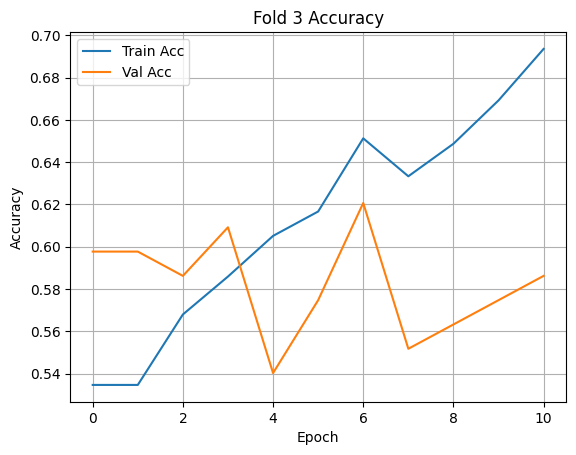

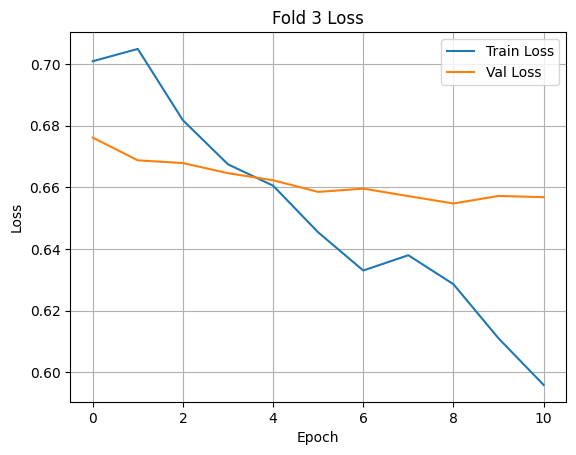

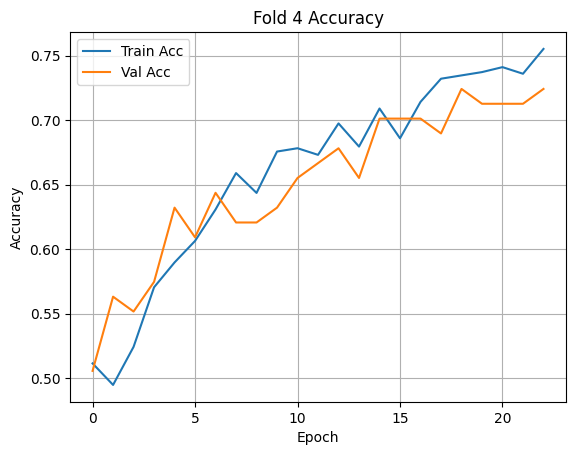

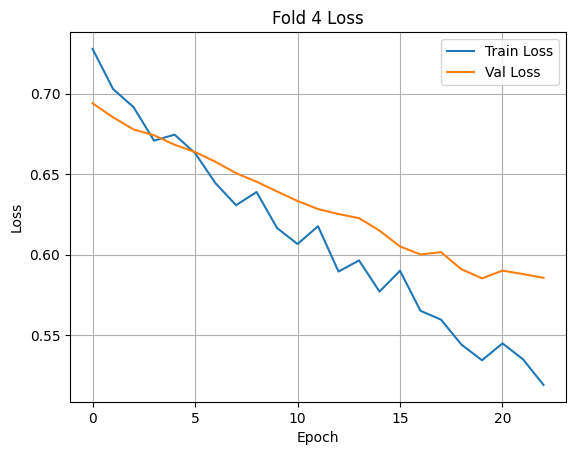

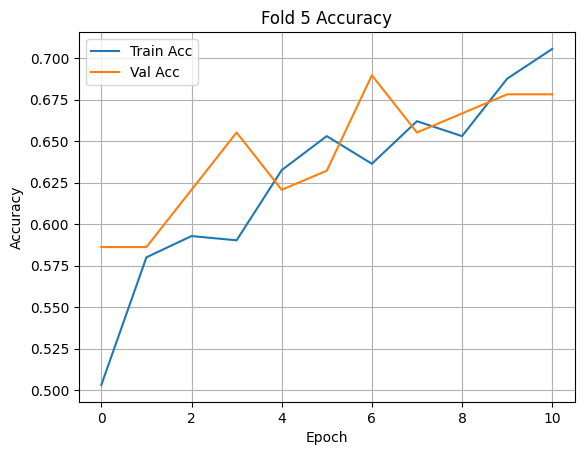

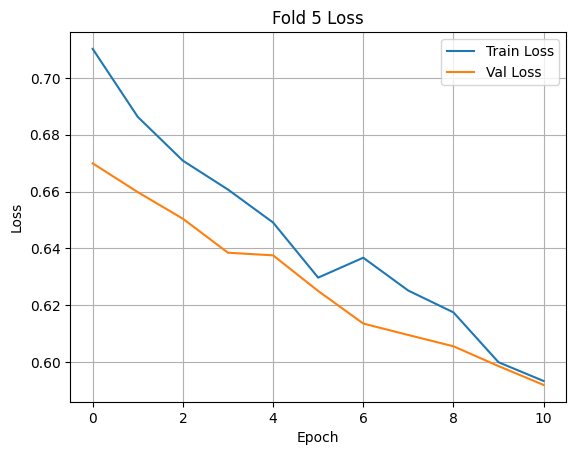

In [ ]:
for i, hist in enumerate(all_histories, 1):
    plt.figure()
    plt.plot(hist['accuracy'], label='Train Acc')
    plt.plot(hist['val_accuracy'], label='Val Acc')
    plt.title(f'Fold {i} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(hist['loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.title(f'Fold {i} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
import pandas as pd

# Giả sử results đã có và bạn đã tạo results_df
results_df = pd.DataFrame(results)

# Tính các chỉ số
accuracy_mean = results_df['accuracy'].mean()
accuracy_std = results_df['accuracy'].std()  # dùng sample std (chia cho n-1)
accuracy_range = results_df['accuracy'].max() - results_df['accuracy'].min()
accuracy_cv_percent = (accuracy_std / accuracy_mean) * 100

# In kết quả
print("📊 Kết quả trung bình:")
print(results_df.mean(numeric_only=True))

print(f"\n✅ CV Accuracy (Mean Accuracy): {accuracy_mean:.4f}")
print(f"📈 Range Accuracy: {accuracy_range:.4f}")
print(f"📉 Accuracy CV% (std/mean): {accuracy_cv_percent:.2f}%")

# Hiển thị bảng kết quả nếu cần
results_df


📊 Kết quả trung bình:
fold         3.000000
accuracy     0.654967
precision    0.681966
recall       0.582926
f1           0.627953
auc          0.726788
dtype: float64

✅ CV Accuracy (Mean Accuracy): 0.6550
📈 Range Accuracy: 0.0293
📉 Accuracy CV% (std/mean): 1.70%


,fold,accuracy,precision,recall,f1,auc
0,1,0.649770,0.681818,0.555556,0.612245,0.749830
1,2,0.668203,0.714286,0.555556,0.625000,0.756796
2,3,0.658986,0.684211,0.596330,0.637255,0.692491
3,4,0.658986,0.673267,0.623853,0.647619,0.724261
4,5,0.638889,0.656250,0.583333,0.617647,0.710562
